# FRIENDS EPISODES ANALYSIS

Visualization of amount of lines per character per season and average of lines said by each character over all seasons. 

We will be using this website [http://livesinabox.com/friends/scripts.shtml] to get the scripts. 

--------

We first start by importing all the libraries we will be using for this exercise. 

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from urllib.request import urlopen
from bs4 import BeautifulSoup
import re
import operator
import numpy

We use Beautifulsoup to parse through the website and show the text. 

In [6]:
web_page = "http://livesinabox.com/friends/scripts.shtml"
response = urlopen(web_page)
html_document = BeautifulSoup(response, features = 'html.parser') 
print(html_document.get_text())



Crazy For Friends - Scripts




















 Last Episode of Friends 
                May 6th!
Recent Updates: Scripts|Spoliers|Pictures



















Friends








-Fan Fiction 
              - Cast 
              - Links 
                          - Spoilers 
Scripts

Select Season 
Season One
Season Two
Season Three
Season Four
Season Five
Season Six
Season Seven
Season Eight
Season Nine
Season Ten


              - Quote Of the Day 
                          - Episode Guide 
              - Home 
 







The 
      Friends




- Chandler 
      Bing 
      - Joey Tribbiani  
      - Ross Geller 
      - Phoebe Buffay 
      - Rachel Green 
                  - Monica Bing 




Pictures




- Matthew 
      Perry
      - Matt LeBlanc 
      - David Schwimmer 
      - Lisa Kudrow 
      - Jennifer Aniston 
      - Courteney Cox  
      - Cast Together 
      - Offical Pictures 
      - Wallpapers




Highlights




- Season 
      One
      - Season Two 
      - Season T

Our objective is to find all tags that contain the hyperlink to each episode's script. 

To make our process easier, we will create a list of links. 

In [8]:
tags = html_document.find_all("a", attrs={"href": re.compile(r'(^season[1-9]{1}/)|(^10.*\.shtml)')})
#regular expression to identify href we need

list_of_links = []

for tag in tags[0:10]: #reducing it to 5 episodes for control
    mother_url = "http://www.livesinabox.com/friends/"
    target_url = mother_url + tag["href"]  #concatenar strings
    print(target_url) #show generated links
    list_of_links.append(target_url)

print(list_of_links) #list of completed links to extract tags

http://www.livesinabox.com/friends/season1/101pilot.htm
http://www.livesinabox.com/friends/season1/102towsg.htm
http://www.livesinabox.com/friends/season1/103thumb.htm
http://www.livesinabox.com/friends/season1/104towgs.htm
http://www.livesinabox.com/friends/season1/105egld.htm
http://www.livesinabox.com/friends/season1/106butt.htm
http://www.livesinabox.com/friends/season1/107towbo.htm
http://www.livesinabox.com/friends/season1/108ndt.htm
http://www.livesinabox.com/friends/season1/109uga.htm
http://www.livesinabox.com/friends/season1/110monk.htm
['http://www.livesinabox.com/friends/season1/101pilot.htm', 'http://www.livesinabox.com/friends/season1/102towsg.htm', 'http://www.livesinabox.com/friends/season1/103thumb.htm', 'http://www.livesinabox.com/friends/season1/104towgs.htm', 'http://www.livesinabox.com/friends/season1/105egld.htm', 'http://www.livesinabox.com/friends/season1/106butt.htm', 'http://www.livesinabox.com/friends/season1/107towbo.htm', 'http://www.livesinabox.com/friends

In order to make sure we are targetting the right hyperlinks, we will check the text of the first hyperlink on our list. 

In [21]:
response = urlopen(list_of_links[0])
html_episode = BeautifulSoup(response, features = 'html.parser')
print(html_episode.get_text()) #bring text from each hyperlink



The One Where Monica Gets a New Roomate (The Pilot-The Uncut Version)


The One Where Monica Gets a New Roommate (The Pilot-The Uncut Version)


Written by: Marta Kauffman & David Crane
Transcribed by: guineapig
Additional transcribing by: Eric Aasen
(Note: The previously unseen parts of this episode are shown in blue text.)


[Scene: Central Perk, Chandler, Joey, Phoebe, and Monica are there.]
Monica: There's nothing to tell! He's just some guy
I work with!
Joey: C'mon, you're going out with the guy! There's
gotta be something wrong with him!
Chandler: All right Joey, be
nice.  So does he have a hump? A hump and a hairpiece?
Phoebe: Wait, does he eat chalk?
(They all stare, bemused.)
Phoebe: Just, 'cause, I don't want her to go through
what I went through with Carl- oh!
Monica: Okay, everybody relax. This is not even a
date. It's just two people going out to dinner and- not having sex.
Chandler: Sounds like a date to me.
[Time Lapse]
Chandler: Alright, so I'm back in high school, I'

Now we will create different functions to process all this information. 

get_episode_tags will look for all tags "b" into each hyperlink provided and return a list. This will give us who is saying each line. 

clean_up will remove all unwanted characters and information we don't need. The resul is a list of names. 

count_lines will count the amount of times that name appears on the list. It will create a dictionary for each link provided, containing the name of the character and a number.

analyse_episode shows the process required to analyze every link using the functions mentioned above. The result is a dictionary of names and a value. This number is the amount of times that character spoke a line in the episode. 

In [9]:
#function to grab url, look for all tags "b", and return list of all tags
def get_episode_tags(episode_url):
    response = urlopen(episode_url)
    html_episode = BeautifulSoup(response, features = "html.parser")

    # ^([a-zA-Z ]+):.*$   
    # re.compile(r'^([a-zA-Z ]+):.*$')
    who_speaks = html_episode.find_all("b") #a revisar para reducir errores en seleccion de character names
    return who_speaks
        

In [10]:
#function to clean up information and return list of tags

def clean_up(tags):
    valid = [] 
    
    for tag in tags:
        
        skip_list = ["commercial break", "closing credits", "opening credits", "none"]
        all_cast = ["chandler", "joey", "monica", "phoebe", "rachel", "ross"]
        
        who = tag.text.lower()
        who = who.strip()
        
        if len(who) == 0: #remove blank spaces
            continue
            
        who = who.replace (":", "") #remove unwanted punctuation marks
        
        if who == "all": #add names when "all" appears
            for name in all_cast:
                valid.append(name)
            continue
            
        if " and " in who: #split and add both names separately
            names = who.split(" and ")
            for name in names:
                valid.append(name)
            continue
        
        if who in skip_list: 
            continue
            
        valid.append(who)
    
    return valid

In [11]:
#function to count names and add them to a dictionary

def count_lines(lines):
    
    counter_of_lines_of = dict()
    
    for name in lines:
        
        if name not in counter_of_lines_of:
            counter_of_lines_of[name] = 1
        
        else:
            previous = counter_of_lines_of[name]
            counter_of_lines_of[name] = previous + 1
            
    return counter_of_lines_of


In [12]:
#function to analyze

def analyze_episode(episode_url):
    who_speaks = get_episode_tags(episode_url)
    all_tags = clean_up(who_speaks)
    return count_lines(all_tags)

Now we merge the list of links with the functions in order to process the first 5 episodes of Friends. 

The result is a dictionary for each hyperlink provided. 

In [13]:
#function to show url link, sorted dictionary with names, and bar graph. 

def show_plot_for_episode(episode, season_number, episode_number):
    names = list(episode.keys())
    values = list(episode.values())

    plt.barh(range(len(episode)), values, color = 'purple', tick_label=names)
    plt.title(f"Amount of lines per character in S{season_number}E{episode_number} ", fontsize = 12)
    plt.xlabel ('Character', fontsize = 8)
    plt.ylabel ('Amount of lines', fontsize = 8)
    plt.show()

In [14]:
#function to get season and episode number

def get_number(url):
    url_components = url.split("/")
    file_name = url_components[-1]
    season = int(file_name[0])
    number = int(file_name[1:3])
    return (season, number)


http://www.livesinabox.com/friends/season1/101pilot.htm {'frannie': 5, 'paul': 17, 'phoebe': 26, 'chandler': 45, 'joey': 48, 'ross': 55, 'rachel': 56, 'monica': 79}


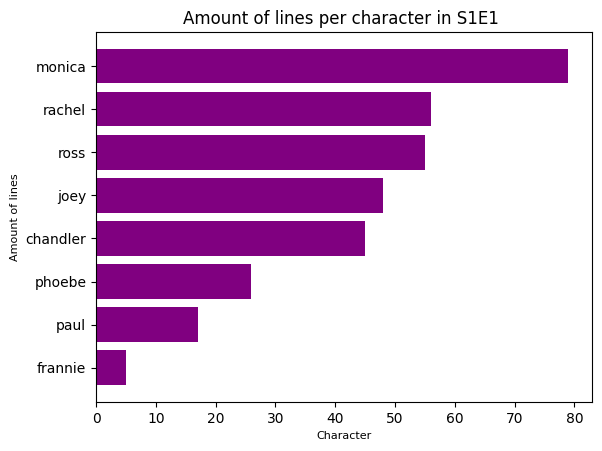

http://www.livesinabox.com/friends/season1/102towsg.htm {'dr. oberman': 2, 'marsha': 4, 'mr. geller': 5, 'robbie': 5, 'susan': 9, 'mrs. geller': 10, 'joey': 11, 'phoebe': 16, 'barry': 16, 'chandler': 18, 'carol': 21, 'monica': 30, 'rachel': 40, 'ross': 65}


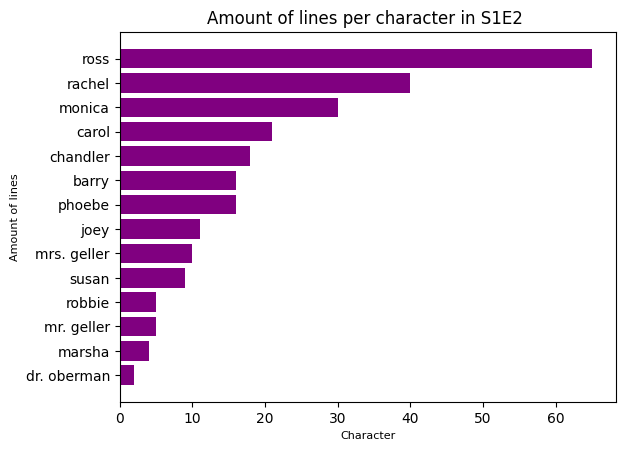

http://www.livesinabox.com/friends/season1/103thumb.htm {'alan': 5, 'paula': 6, 'lizzie': 11, 'rachel': 47, 'joey': 49, 'ross': 54, 'chandler': 57, 'phoebe': 59, 'monica': 73}


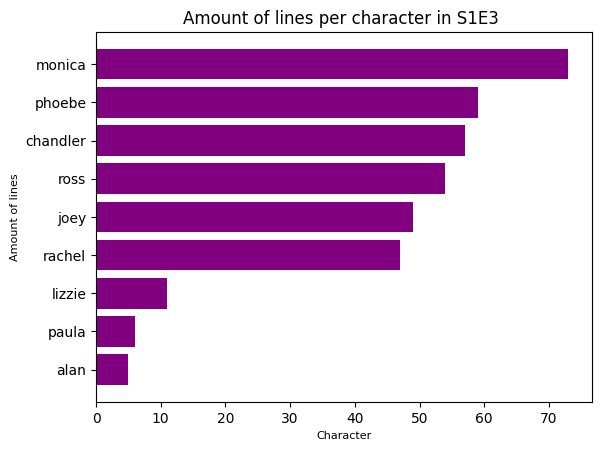

http://www.livesinabox.com/friends/season1/104towgs.htm {'om': 1, 'was': 1, 'the': 1, 'dented': 1, 'both': 1, 'that': 1, 'kiki': 2, 'joanne': 5, 'receptionist': 6, 'joey': 28, 'phoebe': 36, 'chandler': 36, 'ross': 44, 'rachel': 47, 'monica': 52}


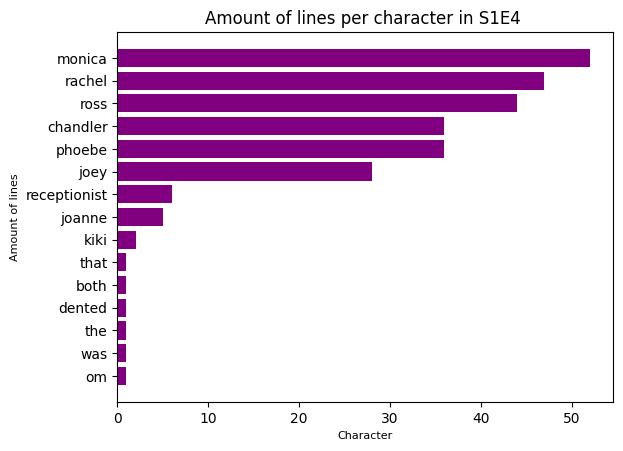

http://www.livesinabox.com/friends/season1/105egld.htm {'bob': 4, 'woman': 8, 'janice': 9, 'angela': 13, 'phoebe': 23, 'monica': 33, 'chandler': 35, 'joey': 36, 'rachel': 37, 'ross': 40}


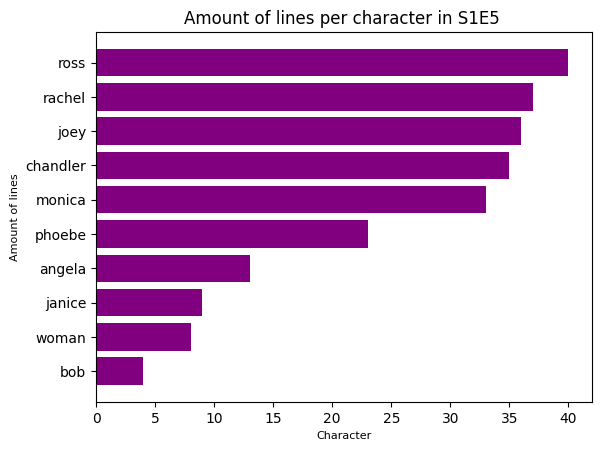

http://www.livesinabox.com/friends/season1/106butt.htm {"ten o'clock": 1, 'director': 6, 'phoebe': 24, 'rachel': 29, 'aurora': 29, 'ross': 36, 'joey': 44, 'monica': 48, 'chandler': 72}


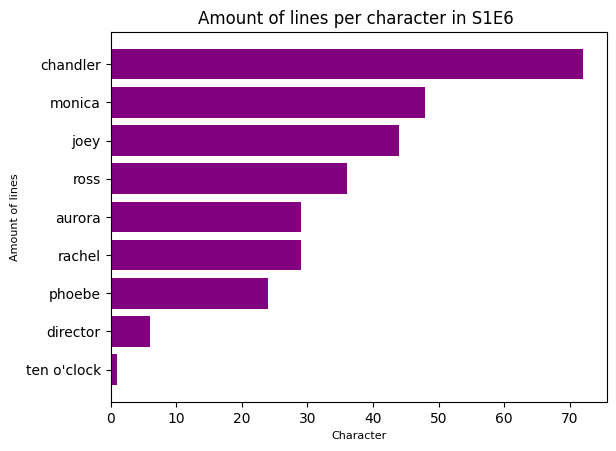

http://www.livesinabox.com/friends/season1/107towbo.htm {'great': 1, 'me': 1, 'that': 1, 'some guy': 1, 'friend\nzone': 1, 'perfection': 1, 'this is not my gum': 1, 'way': 1, 'jll gdcr': 3, 'mr. heckles': 5, 'jill': 14, 'monica': 26, 'phoebe': 28, 'chandler': 28, 'joey': 30, 'rachel': 46, 'ross': 56}


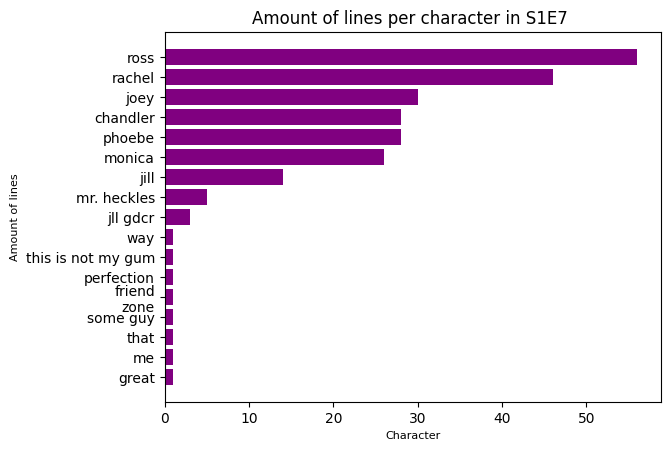

http://www.livesinabox.com/friends/season1/108ndt.htm {'may': 1, 'now': 1, 'is': 1, 'get': 2, 'nurse': 2, 'andrea': 2, 'lowell': 7, 'aunt lillian': 8, 'shelley': 12, 'mr. geller': 13, 'joey': 14, 'phoebe': 19, 'rachel': 21, 'mrs. geller': 23, 'monica': 37, 'chandler': 40, 'ross': 51}


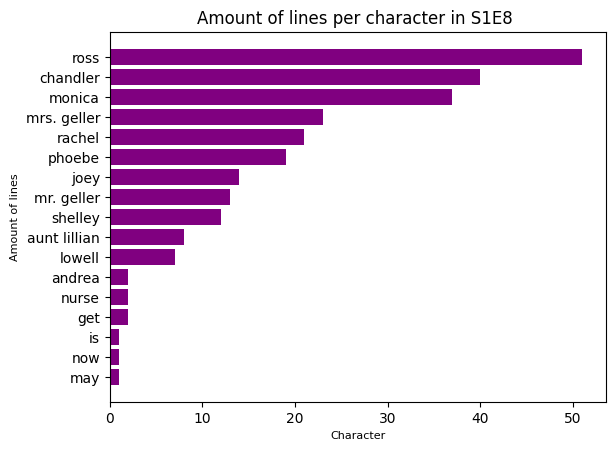

http://www.livesinabox.com/friends/season1/109uga.htm {'have': 1, 'end': 1, 'terry': 2, 'carol': 6, 'susan': 13, 'phoebe': 21, 'chandler': 27, 'joey': 33, 'rachel': 36, 'ross': 37, 'monica': 49}


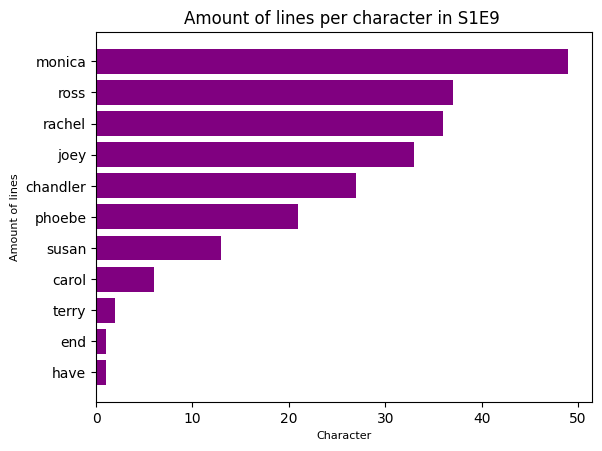

http://www.livesinabox.com/friends/season1/110monk.htm {'fun bobby': 2, 'dick clark': 2, 'sandy': 4, 'janice': 6, 'max': 13, 'rachel': 25, 'joey': 26, 'david': 28, 'monica': 30, 'ross': 36, 'chandler': 38, 'phoebe': 56}


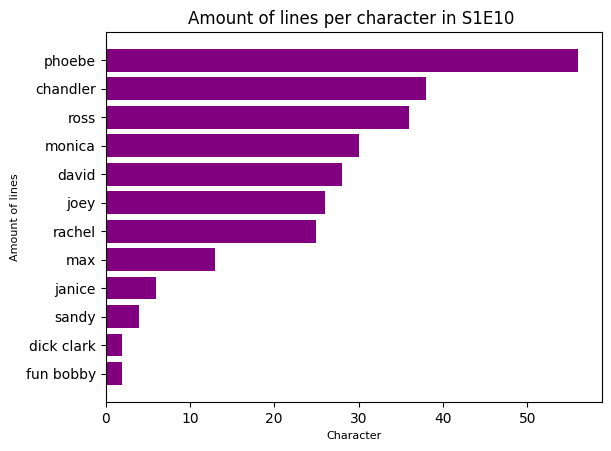

[{'frannie': 5, 'paul': 17, 'phoebe': 26, 'chandler': 45, 'joey': 48, 'ross': 55, 'rachel': 56, 'monica': 79}, {'dr. oberman': 2, 'marsha': 4, 'mr. geller': 5, 'robbie': 5, 'susan': 9, 'mrs. geller': 10, 'joey': 11, 'phoebe': 16, 'barry': 16, 'chandler': 18, 'carol': 21, 'monica': 30, 'rachel': 40, 'ross': 65}, {'alan': 5, 'paula': 6, 'lizzie': 11, 'rachel': 47, 'joey': 49, 'ross': 54, 'chandler': 57, 'phoebe': 59, 'monica': 73}, {'om': 1, 'was': 1, 'the': 1, 'dented': 1, 'both': 1, 'that': 1, 'kiki': 2, 'joanne': 5, 'receptionist': 6, 'joey': 28, 'phoebe': 36, 'chandler': 36, 'ross': 44, 'rachel': 47, 'monica': 52}, {'bob': 4, 'woman': 8, 'janice': 9, 'angela': 13, 'phoebe': 23, 'monica': 33, 'chandler': 35, 'joey': 36, 'rachel': 37, 'ross': 40}, {"ten o'clock": 1, 'director': 6, 'phoebe': 24, 'rachel': 29, 'aurora': 29, 'ross': 36, 'joey': 44, 'monica': 48, 'chandler': 72}, {'great': 1, 'me': 1, 'that': 1, 'some guy': 1, 'friend\nzone': 1, 'perfection': 1, 'this is not my gum': 1, 'w

In [40]:
#analyze list of links with first 5 episodes and show graph for each one

#conjunto de funciones que hacen al proceso de procesamiento de episodios

episode_analysis = []
for url in list_of_links:
    analysis = analyze_episode(url)
    sorted_analysis = dict(sorted(analysis.items(), key=operator.itemgetter(1), reverse = False))
    episode_analysis.append(sorted_analysis)
    print(url, sorted_analysis)
    season, episode = get_number(url)
    show_plot_for_episode(sorted_analysis, season, episode)

print(episode_analysis)

In [73]:
def create_character_list(episodes, name):
    character = []
    for episode in episodes:
        if name in episode:
            number_of_lines = episode[name]
            character.append(number_of_lines)
    return character



## cambie aqui

def create_dictionary(episodes, names):
    d_friends = {}
    for character in characters:
        lines = create_character_list(episodes, character)
        d_friends[character] = lines
    return d_friends



characters = ["monica", "chandler", "ross", "joey", "phoebe", "rachel", "janice"]
dict_characters = create_dictionary(episode_analysis, characters)



Numpy average + matplotlib de average

In [68]:
print(episode_analysis[3])


{'om': 1, 'was': 1, 'the': 1, 'dented': 1, 'both': 1, 'that': 1, 'kiki': 2, 'joanne': 5, 'receptionist': 6, 'joey': 28, 'phoebe': 36, 'chandler': 36, 'ross': 44, 'rachel': 47, 'monica': 52}


In [76]:
def average(list):
    if len(list) > 0:
        return sum(list)/len(list)
    return 0

for character in dict_characters:
    number = dict_characters[character]
    print(character, average(number))

monica 45.7
chandler 39.6
ross 47.4
joey 31.9
phoebe 30.8
rachel 38.4
janice 7.5
